In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


### Feature Engineering Conclusion
*Before there were 4 features, And now there are 19 features in total including-*
| Category           | Purpose             |
| ------------------ | ------------------- |
| Time features      | Seasonality         |
| Lag features       | Memory              |
| Rolling features   | Trend & volatility  |
| Aggregate features | Indicate-Behavior   |

In [2]:
df = pd.read_csv("../data/processed/featured_data.csv", parse_dates=["date"])

In [3]:
df.dtypes

date               datetime64[ns]
store                       int64
item                        int64
sales                       int64
year                        int64
month                       int64
week                        int64
day                         int64
dayofweek                   int64
is_weekend                  int64
sales_lag_1               float64
sales_lag_7               float64
sales_lag_14              float64
sales_lag_28              float64
rolling_mean_7            float64
rolling_mean_14           float64
rolling_mean_28           float64
store_avg_sales           float64
item_avg_sales            float64
dtype: object

## Data Split - Train & Validation

In [4]:
train_df = df[df["date"] < "2017-01-01"]
val_df   = df[df["date"] >= "2017-01-01"].copy()

In [5]:

def create_sequences(series, window=28):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


# SCALE TARGET SERIES
scaler_y = MinMaxScaler()

train_scaled = scaler_y.fit_transform(train_df["sales"].values.reshape(-1,1))
val_scaled   = scaler_y.transform(val_df["sales"].values.reshape(-1,1))


#CREATE SEQUENCES
X_train_seq, y_train_seq = create_sequences(train_scaled, 28)
X_val_seq, y_val_seq     = create_sequences(val_scaled, 28)


# reshape for LSTM
X_train_seq = X_train_seq.reshape(-1,28,1)
X_val_seq   = X_val_seq.reshape(-1,28,1)


In [6]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(28,1)),
    Dropout(0.2),
    LSTM(32),
    Dense(1, activation="sigmoid")   # IMPORTANT
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

C:\Users\draza\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 28, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 28, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
es = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=25,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

Epoch 1/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 152s 13ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 2/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 146s 13ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 3/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 147s 13ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 4/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 145s 13ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 5/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 146s 13ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 6/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 148s 13ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 7/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 146s 13ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 8/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 149s 13ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 9/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 147s 13ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 10/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 147s 13ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 11/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 155s 14ms/step - loss: 0

In [8]:
val_preds_scaled = model.predict(X_val_seq)

val_preds = scaler_y.inverse_transform(val_preds_scaled)

y_val_actual = scaler_y.inverse_transform(
    y_val_seq.reshape(-1,1)
)


5703/5703 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step


In [9]:
rmse_lstm = np.sqrt(mean_squared_error(y_val_actual, val_preds))
mape_lstm = np.mean(np.abs((y_val_actual - val_preds) / y_val_actual)) * 100

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAPE:", mape_lstm)

LSTM RMSE: 8.76659941147079
LSTM MAPE: 13.907831816380096


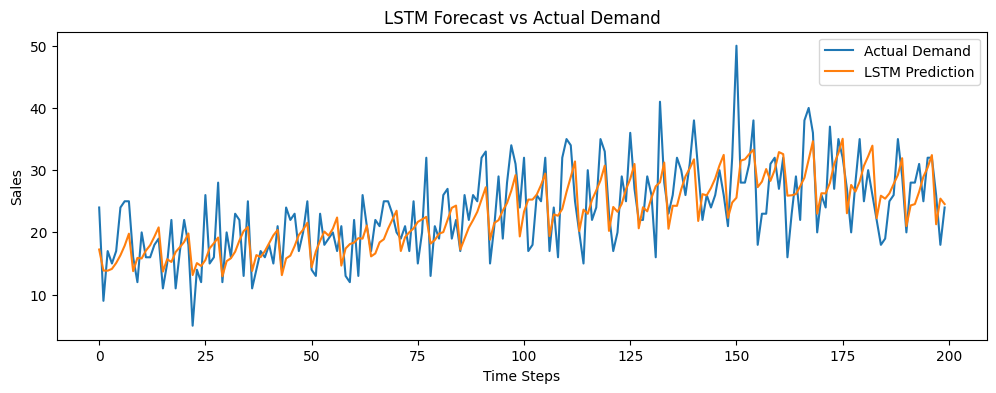

In [10]:
plt.figure(figsize=(12,4))

plt.plot(y_val_actual[:200], label="Actual Demand")
plt.plot(val_preds[:200], label="LSTM Prediction")

plt.title("LSTM Forecast vs Actual Demand")
plt.xlabel("Time Steps")
plt.ylabel("Sales")
plt.legend()
plt.show()

### Saving Model and Predictions

In [11]:
model.save("../models/lstm_model.keras")

import joblib
joblib.dump(scaler_y, "../models/lstm_scaler.save")
joblib.dump(val_preds, "../models/lstm_preds.joblib")

['../models/lstm_preds.joblib']

### Loading Model Back

In [11]:
from tensorflow.keras.models import load_model
model = load_model("../models/lstm_model.keras")

C:\Users\draza\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Multivariate LSTM

In [16]:
# [sales, lag, rolling, calendar features] -> predict sales
FEATURES = [col for col in df.columns if col not in ["date", "sales"]]
TARGET = "sales"

In [17]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df[FEATURES + [TARGET]])
val_scaled   = scaler.transform(val_df[FEATURES + [TARGET]])

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df[FEATURES + [TARGET]])
val_scaled   = scaler.transform(val_df[FEATURES + [TARGET]])

In [19]:
# Creating Sequence - Now each timestep has multiple features
import numpy as np

def create_multivariate_sequences(data, window=28):
    X, y = [], []
    
    for i in range(len(data) - window):
        X.append(data[i:i+window, :-1])   # all features
        y.append(data[i+window, -1])      # target (sales)
        
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_multivariate_sequences(train_scaled, 28)
X_val_seq, y_val_seq     = create_multivariate_sequences(val_scaled, 28)

In [20]:
print(X_train_seq.shape)

(716472, 28, 17)


In [21]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(28, X_train_seq.shape[2])),
    Dropout(0.2),
    
    LSTM(64),
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

C:\Users\draza\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 28, 128)             │          74,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 28, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 126,273 (493.25 KB)

 Trainable params: 126,273 (493.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
es = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=25,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

Epoch 1/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 314s 28ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 2/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 304s 27ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 3/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 312s 28ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 4/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 328s 29ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 5/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 304s 27ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 6/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 303s 27ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 7/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 301s 27ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 8/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 302s 27ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 9/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 300s 27ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 10/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 302s 27ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 11/25
11195/11195 ━━━━━━━━━━━━━━━━━━━━ 302s 27ms/step - loss: 0